In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [12]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200  # number of students

data = {
    'study_hours': np.random.randint(1, 10, n),
    'attendance': np.random.randint(50, 100, n),
    'sleep_hours': np.random.randint(4, 9, n),
    'previous_score': np.random.randint(40, 95, n),
}

df = pd.DataFrame(data)

# create realistic final score
df['final_score'] = (
    0.3 * df['study_hours'] +
    0.3 * df['attendance']/10 +
    0.2 * df['sleep_hours'] +
    0.2 * df['previous_score']/10
) * 10 + np.random.normal(0, 5, n)

df.head()

,study_hours,attendance,sleep_hours,previous_score,final_score
0,7,50,4,80,60.640205
1,4,60,7,78,57.193308
2,8,77,8,40,65.359725
3,5,74,4,42,50.588719
4,7,99,5,52,62.003498


       study_hours  attendance  sleep_hours  previous_score  final_score
count    200.00000  200.000000   200.000000      200.000000   200.000000
mean       5.07000   76.410000     6.115000       67.260000    64.047927
std        2.63435   13.964488     1.470574       16.293551    11.168667
min        1.00000   50.000000     4.000000       40.000000    36.563293
25%        3.00000   66.000000     5.000000       53.000000    56.139466
50%        5.00000   77.000000     6.000000       67.000000    64.319785
75%        7.00000   87.000000     7.250000       80.000000    72.711960
max        9.00000   99.000000     8.000000       94.000000    88.480856


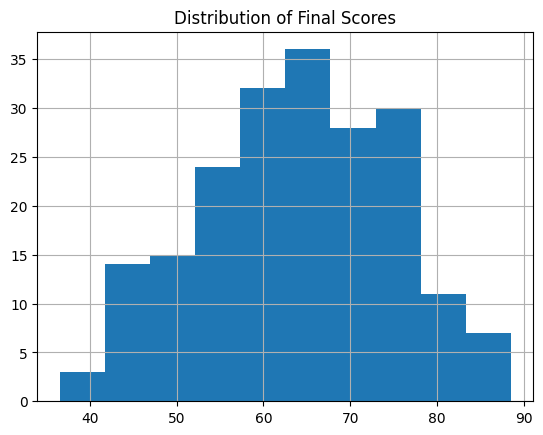

In [13]:
print(df.describe())

import matplotlib.pyplot as plt
df['final_score'].hist()
plt.title("Distribution of Final Scores")
plt.show()

In [14]:
X = df[['study_hours', 'attendance', 'sleep_hours', 'previous_score']]
y = df['final_score']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, rmse, r2]

results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
results_df

,MAE,RMSE,R2
Linear Regression,3.715651,4.637371,0.782684
Random Forest,5.226165,6.377091,0.589045
Decision Tree,7.334230,9.260007,0.133495


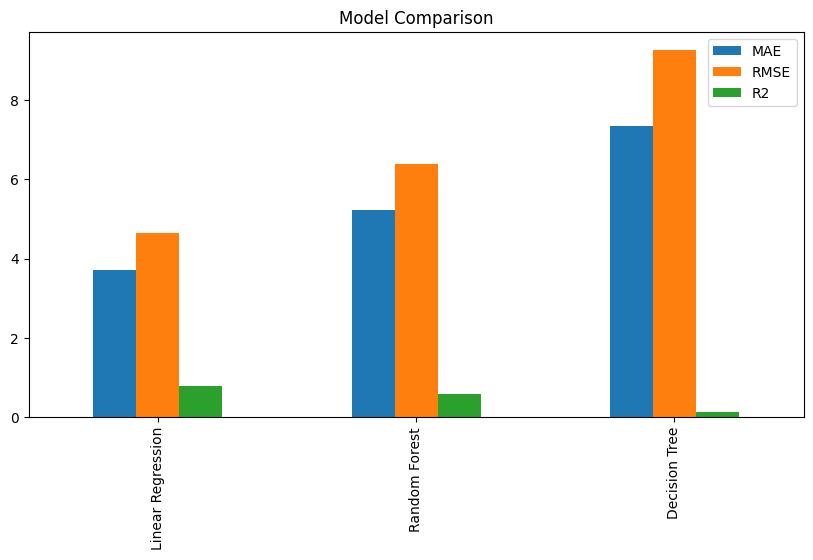

In [17]:
results_df.plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.show()

In [18]:
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

RandomForestRegressor()

In [19]:
new_student = [[7, 90, 7, 80]]

prediction = best_model.predict(new_student)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 74.22303336859272


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


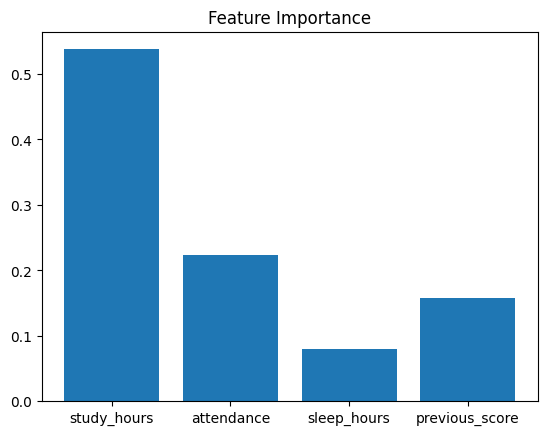

In [20]:
importances = best_model.feature_importances_

features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

In [21]:
df.to_csv("dataset.csv", index=False)

In [22]:
from google.colab import files
files.download("dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>